# Data Cleaning

In [1]:
import sys
import os
import logging
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Add project root to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load environment and config (force refresh)
load_dotenv(project_root / '.env', override=True)
from soeSpotify import config

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
palette = sns.color_palette("viridis", as_cmap=False)

print("Setup complete.")

Setup complete.


In [2]:
print("Loading processed datasets...")

# Load raw processed data (before analytics stage transformations)
df_processed_tracks = pd.read_parquet(config.PROCESSED_TRACKS)
df_processed_artists = pd.read_parquet(config.PROCESSED_ARTISTS)
df_processed_albums = pd.read_parquet(config.PROCESSED_ALBUMS)
df_processed_features = pd.read_parquet(config.PROCESSED_TRACK_FEATURES)

print(f"Processed Tracks loaded:   {len(df_processed_tracks):,}")
print(f"Processed Artists loaded:  {len(df_processed_artists):,}")
print(f"Processed Albums loaded:   {len(df_processed_albums):,}")
print(f"Processed Features loaded: {len(df_processed_features):,}")


Loading processed datasets...
Processed Tracks loaded:   101,939
Processed Artists loaded:  56,129
Processed Albums loaded:   75,511
Processed Features loaded: 101,909


## Analytics Stage Transformations

Building business-ready tables: denormalization, column selection, and type casting.


In [3]:
# Build Analytics Artists Table
print("Building analytics artists table...")

df_artists = df_processed_artists[[
    "artist_id", "artist_name", "artist_popularity", "followers", "type",
    "genres"
]].copy()

# Ensure correct types
df_artists["artist_popularity"] = df_artists["artist_popularity"].fillna(0).astype("int64")
df_artists["followers"] = df_artists["followers"].fillna(0).astype("int64")

print(f"Analytics artists: {len(df_artists):,} rows")


Building analytics artists table...
Analytics artists: 56,129 rows


In [4]:
# Build Analytics Albums Table (with artist denormalization)
print("Building analytics albums table...")

# FILTER: Only keep albums that reference an existing artist (Foreign Key constraint)
valid_artist_ids = df_artists["artist_id"].unique()
df_albums = df_processed_albums[df_processed_albums["artist_id"].isin(valid_artist_ids)].copy()

print(f"Filtered albums: {len(df_albums):,}/{len(df_processed_albums):,} reference valid artists")

# Prepare artist columns with prefix to avoid conflicts
artists_cols = df_artists.copy()
artists_cols = artists_cols.rename(
    columns={c: f"artist_{c}" for c in df_artists.columns}
)

# Join albums with artists
df_albums = df_albums.merge(
    artists_cols,
    left_on="artist_id",
    right_on="artist_artist_id",
    how="left",
)

# Select and rename final columns
df_albums = df_albums[[
    "album_id", "album_name", "album_type", "release_date", "total_tracks",
    "uri", "artist_id", "artist_artist_name", "artist_followers",
    "artist_artist_popularity"
]].copy()

df_albums = df_albums.rename(
    columns={
        "artist_artist_name": "artist_name",
        "artist_artist_popularity": "artist_popularity",
    }
)

# Ensure correct types for database sync
df_albums["total_tracks"] = df_albums["total_tracks"].fillna(0).astype("int64")
df_albums["artist_followers"] = df_albums["artist_followers"].fillna(0).astype("int64")
df_albums["artist_popularity"] = df_albums["artist_popularity"].fillna(0).astype("int64")

print(f"Analytics albums: {len(df_albums):,} rows")


Building analytics albums table...
Filtered albums: 74,991/75,511 reference valid artists
Analytics albums: 74,991 rows


In [5]:
# Prepare Analytics Track Features
print("Preparing analytics track features...")

# Get high-level Spotify audio features from processed tracks
spotify_features = [
    "track_id", "acousticness", "danceability", "energy",
    "instrumentalness", "key", "liveness", "loudness", "mode",
    "speechiness", "tempo", "time_signature", "valence",
]
audio_cols = [c for c in spotify_features if c in df_processed_tracks.columns]

# Get lyrics features from the features dataframe
lyrics_features = [
    "mean_syllables_word", "mean_words_sentence", "n_sentences",
    "n_words", "sentence_similarity", "vocabulary_wealth",
]
lyrics_cols = [c for c in lyrics_features if c in df_processed_features.columns]

# Start with high-level audio features from tracks
df_track_features_audio = df_processed_tracks[audio_cols].copy()
df_track_features_audio = df_track_features_audio.drop_duplicates(subset=["track_id"])

print(f"Analytics track features audio: {len(df_track_features_audio):,} rows")
print(f"Lyrics feature columns available: {lyrics_cols}")


Preparing analytics track features...
Analytics track features audio: 101,939 rows
Lyrics feature columns available: ['mean_syllables_word', 'mean_words_sentence', 'n_sentences', 'n_words', 'sentence_similarity', 'vocabulary_wealth']


## Genre Preprocessing & Enrichment


The genres column contains a list of genres for most artists. The genres defined are extremely granular such as 	danish pop rock or quebecois hip hop. in the first step we split up the list and only retain a primary and a secondary genre. There are over 2000 unique genres.

In [6]:
import ast

def _parse_genres(val):
    if pd.isna(val):
        return {"primary_genre": "", "secondary_genre": ""}

    # Already a list-like object
    if isinstance(val, (list, tuple)):
        primary = val[0] if len(val) >= 1 else ""
        secondary = val[1] if len(val) >= 2 else ""
        return {"primary_genre": primary, "secondary_genre": secondary}

    # String representation (e.g. "['rock', 'indie']" or "[]")
    if isinstance(val, str):
        s = val.strip()
        if s in ("", "[]"):
            return {"primary_genre": "", "secondary_genre": ""}
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple)):
                primary = parsed[0] if parsed else ""
                secondary = parsed[1] if len(parsed) > 1 else ""
                return {"primary_genre": primary, "secondary_genre": secondary}
        except Exception:
            pass
        # Fallback: split on commas inside the brackets
        s2 = s.strip("[]")
        parts = [p.strip().strip("\"\'") for p in s2.split(",") if p.strip()]
        primary = parts[0] if parts else ""
        secondary = parts[1] if len(parts) > 1 else ""
        return {"primary_genre": primary, "secondary_genre": secondary}

    return {"primary_genre": "", "secondary_genre": ""}

# Apply parser and append columns to df_artists
_parsed = df_artists["genres"].apply(_parse_genres).apply(pd.Series)
df_artists = pd.concat([df_artists, _parsed], axis=1)

# Show the new columns
df_artists[["genres", "primary_genre", "secondary_genre"]].head()

,genres,primary_genre,secondary_genre
0,"['sertanejo', 'sertanejo pop', 'sertanejo trad...",sertanejo,sertanejo pop
1,[],,
2,['danish pop rock'],danish pop rock,
3,['uk alternative pop'],uk alternative pop,
4,['french baroque'],french baroque,


In [7]:
df_artists["primary_genre"].unique()

<ArrowStringArray>
[          'sertanejo',                    '',     'danish pop rock',
  'uk alternative pop',      'french baroque', 'classic finnish pop',
              'pagode',    'abstract hip hop',     'classical cello',
               'brega',
 ...
             'klezmer',        'chill groove',  'finnish rockabilly',
          'kinderchor',         'turin indie',   'southampton indie',
           'slow core',          'fijian pop',       'swiss hip hop',
            'nu metal']
Length: 2154, dtype: str

In [8]:
primary_genre_counts = df_artists["primary_genre"].value_counts()
rare_primary_genres = primary_genre_counts[primary_genre_counts < 2]
print(len(rare_primary_genres))

413


There are over 2000 unique genres. However over 400 of these genres only occur for one artist. These are meaningless as categorical variables as they make their own unique categories.

As a secondary catch we will map the genres to broader, bigger categories as a second tier category, that can be used as a fall-back option in recommenders, when the more specific genre is exhausted. As a result of this for example "swiss hip hop" and "abstract hip hop" will be in teh same broad category of "hip hop".

In [9]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
model = SentenceTransformer('all-MiniLM-L6-v2')

broad_genres = ['pop', 'rock', 'hip hop', 'indie', 'electronic', 
                'folk', 'r&b', 'jazz', 'classical', 'metal', 'house', 'blues', 'world']

broad_embeddings = model.encode(broad_genres)

def assign_broad_genre(genre):
    genre_emb = model.encode([genre])
    sims = cosine_similarity(genre_emb, broad_embeddings)[0]
    return broad_genres[np.argmax(sims)]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 467.08it/s]


In [11]:
all_genres = pd.concat([df_artists['primary_genre'], df_artists['secondary_genre']]).unique()
print(f"Total unique genres: {len(all_genres)}")

Total unique genres: 2347


In [12]:
genre_to_broad = {genre: assign_broad_genre(genre) for genre in all_genres if genre}
df_artists['primary_genre_broad'] = df_artists['primary_genre'].map(genre_to_broad).fillna(df_artists['primary_genre'])
df_artists['secondary_genre_broad'] = df_artists['secondary_genre'].map(genre_to_broad).fillna(df_artists['secondary_genre'])   

In [13]:
mask = (
    df_artists[['primary_genre', 'secondary_genre', 'primary_genre_broad', 'secondary_genre_broad']]
    .apply(lambda col: col.notna() & (col.str.strip() != ''))
    .all(axis=1)
)

df_artists[mask][['primary_genre', 'secondary_genre', 'primary_genre_broad', 'secondary_genre_broad']].head(10)

,primary_genre,secondary_genre,primary_genre_broad,secondary_genre_broad
0,sertanejo,sertanejo pop,world,pop
11,pagode,sertanejo,rock,world
18,sertanejo,sertanejo tradicional,world,classical
22,sertanejo,sertanejo tradicional,world,classical
23,brega,sertanejo tradicional,r&b,classical
26,abstract hip hop,experimental hip hop,hip hop,hip hop
33,diva house,hip house,house,house
43,deep chiptune,filter house,rock,house
44,blues,blues-rock,blues,blues
49,pagode,sertanejo,rock,world


In [14]:
# Build Analytics Genres Table (explode into individual genre rows)
print("Building analytics genres table...")

genres_list = []

for _, row in df_artists.iterrows():
    artist_id = row["artist_id"]
    artist_name = row["artist_name"]
    genres = row["genres"]

    if isinstance(genres, str):
        # Handle string representation of list
        if genres.startswith("[") and genres.endswith("]"):
            import ast
            try:
                genre_list = ast.literal_eval(genres)
            except (ValueError, SyntaxError):
                genre_list = [genres]
        else:
            genre_list = [genres]
    elif isinstance(genres, list):
        genre_list = genres
    else:
        continue

    for genre in genre_list:
        if genre:  # Skip empty genres
            genres_list.append({
                "artist_id": artist_id,
                "artist_name": artist_name,
                "genre": genre,
            })

df_genres = pd.DataFrame(genres_list)

# FILTER: Only keep genres for valid artists
df_genres = df_genres[df_genres["artist_id"].isin(valid_artist_ids)].copy()

print(f"Analytics genres: {len(df_genres):,} genre mappings")


Building analytics genres table...
Analytics genres: 87,202 genre mappings


In [15]:
print(df_genres.columns)

Index(['artist_id', 'artist_name', 'genre'], dtype='str')


## Podcast filtering

The data contains not only music but interviews, podcasts, comedy and talk shows as well. These need to be filtered out, however there is no one clear indicator of these.
After exploration in the databse and domain knowledge here are some meaningful guidelines detecting podcasts, interviews, audiobooks etc:
- speechiness is above 0.6
- duration is typically longer for podcasts compared to music
- intrumentalness is below 0.1 

But to all these rules exceptions apply.

In [16]:
df_processed_tracks['duration_minutes'] = df_processed_tracks['duration_ms'] / 60000


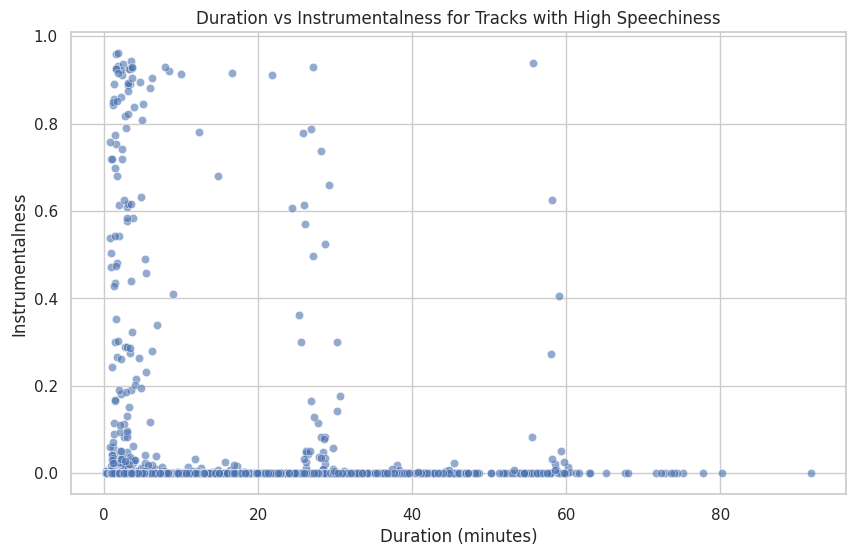

In [17]:
df_filtered_speechiness = df_processed_tracks[df_processed_tracks['speechiness'] > 0.5] # podcast, interview, storybook
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered_speechiness, x='duration_minutes', y='instrumentalness', alpha=0.6)
plt.title('Duration vs Instrumentalness for Tracks with High Speechiness')
plt.xlabel('Duration (minutes)')
plt.ylabel('Instrumentalness')
plt.show()


We see that for the subset with speechiness above 0.6 the majority of the tracks have low instrumentalness and rather longer duration. This is a clear sign for podcasts. Even shorter tracks with low instrumentalness are presumably not music due to the combination of high speechiness and low instruemntalness.

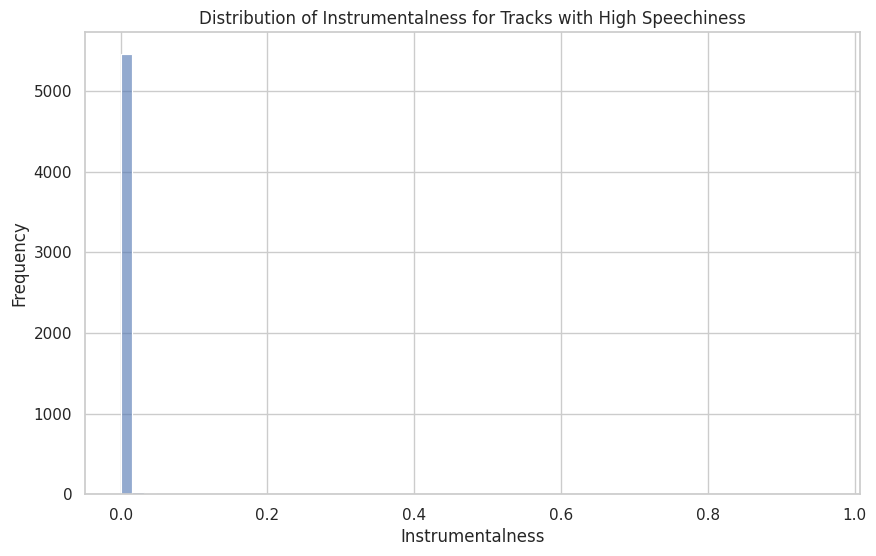

In [18]:
#create a histogram of instrumentalness for tracks that have speechiness above 0.6
df_filtered = df_processed_tracks[df_processed_tracks['speechiness'] > 0.6]
plt.figure(figsize=(10, 6))
sns.histplot(data=df_filtered, x='instrumentalness', bins=60, alpha=0.6)
plt.title('Distribution of Instrumentalness for Tracks with High Speechiness')
plt.xlabel('Instrumentalness')
plt.ylabel('Frequency')
plt.show()


In [19]:
num_tracks = len(df_filtered)
num_instrumental = (df_filtered['instrumentalness'] > 0.1).sum()
percentage_instrumental = (num_instrumental / num_tracks) * 100
print(f"Total tracks with speechiness > 0.6: {num_tracks}")
print(f"Tracks with instrumentalness > 0.1: {num_instrumental}")
print(f"Percentage instrumental: {percentage_instrumental:.2f}%")

Total tracks with speechiness > 0.6: 5593
Tracks with instrumentalness > 0.1: 80
Percentage instrumental: 1.43%


Verdict is to exclude all tracks with speechiness above 0.6. We risk the exclusion of 80 potential music tracks. However the cost of leaving a podcast in is greater, than the loss of excluding music so we decided to set the cutoff thresholds accordingly.

We move on to lower speechiness tracks. namely the next bin is speechiness between 0.5 and 0.6.

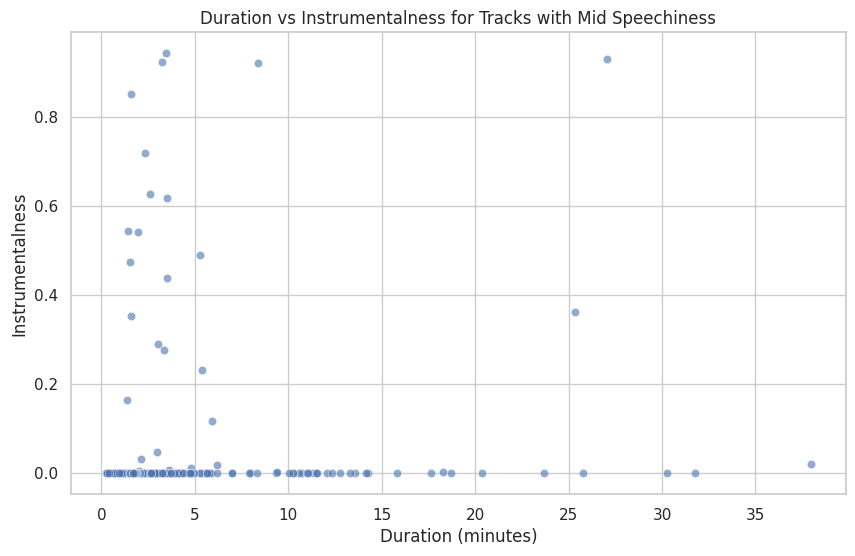

In [20]:
df_filtered = df_processed_tracks[(df_processed_tracks['speechiness'] <= 0.6) & (df_processed_tracks['speechiness'] > 0.55)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='duration_minutes', y='instrumentalness', alpha=0.6)
plt.title('Duration vs Instrumentalness for Tracks with Mid Speechiness')
plt.xlabel('Duration (minutes)')
plt.ylabel('Instrumentalness')
plt.show()


Here due to the lower threshold of speechiness we will also require low instrumentalness (under 0.1) for cutoff.

In [21]:
df_filtered_instrumental = df_processed_tracks[(df_processed_tracks['speechiness'] < 0.1)]

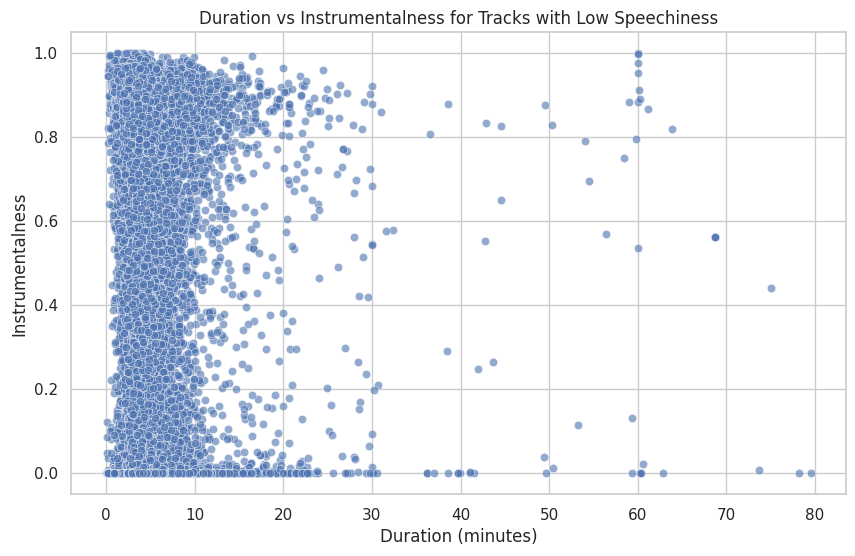

In [22]:
df_filtered = df_processed_tracks[(df_processed_tracks['speechiness'] <= 0.5)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='duration_minutes', y='instrumentalness', alpha=0.6)
plt.title('Duration vs Instrumentalness for Tracks with Low Speechiness')
plt.xlabel('Duration (minutes)')
plt.ylabel('Instrumentalness')
plt.show()


For speechiness under 0.5, we clearly see the instrumentalness shoots up substantially compared to the previous two graphs.

The dataset was again checked and it was noticed that we still had some non songs in the dataset. These playlists was removed adhoc.

In [23]:
# remove playlist Animal Stories and Mythologies
stories_mask = (
    df_processed_tracks["playlist"]
    .fillna("")
    .str.lower()
    .str.strip()
    .isin(["animal stories", "mythologies","learn chinese","learn arabic","learn swedish","learn italian","sci-fi radio dramas","learn french","learn russian","showstopper: season one"])
)

df_filtered_playlist = df_processed_tracks.loc[stories_mask]


Remove the track that are episodes or lessons.

In [24]:
episode_lesson_mask = df_processed_tracks["track_name"].fillna("").str.contains(
    r"\b(episode|lesson)\s*\d+\b",
    case=False,
    regex=True
)

df_filtered_episodes = df_processed_tracks.loc[episode_lesson_mask]

/tmp/ipykernel_95739/1286886727.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  episode_lesson_mask = df_processed_tracks["track_name"].fillna("").str.contains(


### Conclusion
From the perspective of the project the exclusion of a few music tracks is less of an issue, compared to leaving in some non-music tracks. With that being said we will apply the following exclusion logic for non-music tracks.
Exclude all tracks with:
- speechiness above 0.5
- duration above 10 minutes (also full concert recordings and such)
- speechiness between 0.5 and 0.6 and instrumentalness under 0.1

Disclaimer: values of 0 in instrumentalness likely denote missing values rather than no instrumentalness.


In [43]:
print(f"Original processed tracks: {len(df_processed_tracks):,}")


Original processed tracks: 101,939


Mark all tracks not relevant as "podcasts".

In [44]:
# Create podcast removal mask
podcast_mask = ~(
    (df_processed_tracks['speechiness'] <= 0.5) &
    (df_processed_tracks['duration_minutes'] <= 10) &
    ~(
        (df_processed_tracks['speechiness'] > 0.5) & 
        (df_processed_tracks['speechiness'] <= 0.6) & 
        (df_processed_tracks['instrumentalness'] < 0.1)
    ) &
    ~df_processed_tracks["track_id"].isin(df_filtered_episodes["track_id"]) &
    ~df_processed_tracks["track_id"].isin(df_filtered_playlist["track_id"])
)

# Mark removed rows as podcasts
df_processed_tracks["is_podcast"] = "no"
df_processed_tracks.loc[podcast_mask, "is_podcast"] = "yes"

df_tracks = df_processed_tracks.copy()

print(df_tracks["is_podcast"].value_counts())


is_podcast
no     94429
yes     7510
Name: count, dtype: int64


## Building Final Analytics Tables with Joins

Combining all cleaned and preprocessed data with full denormalization and context.


In [45]:
# Build Analytics Tracks Table (denormalized with full context)
print("Building analytics tracks table with full joins...")

# Create a copy to avoid side effects
df_base = df_tracks#.copy()

# CLEAN: artists_id is often "['ID']", extract the first one safely
is_list_format = df_base["artists_id"].str.contains(r"\[", na=False)
if is_list_format.any():
    df_base.loc[is_list_format, "artists_id"] = df_base.loc[is_list_format, "artists_id"].str.extract(r"'(.*?)'")[0]

# FILTER: Only keep tracks that reference valid artists AND valid albums
valid_album_ids = df_albums["album_id"].unique()

df_tracks_filtered = df_base[
    (df_base["artists_id"].isin(valid_artist_ids)) & 
    (df_base["album_id"].isin(valid_album_ids))
]#.copy()

print(f"Filtered tracks: {len(df_tracks_filtered):,}/{len(df_base):,} have valid references")

# Join tracks with features
df_tracks_final = df_tracks_filtered.merge(df_processed_features, on="track_id", how="left")


Building analytics tracks table with full joins...
Filtered tracks: 101,144/101,939 have valid references


In [46]:
# Join with artists
artists_cols = df_artists.copy()
artists_cols = artists_cols.rename(
    columns={c: f"artist_{c}" for c in df_artists.columns}
)
df_tracks_final = df_tracks_final.merge(
    artists_cols,
    left_on="artists_id",
    right_on="artist_artist_id",
    how="left",
)

# Join with albums
albums_cols = df_albums.copy()
albums_cols = albums_cols.rename(
    columns={c: f"album_{c}" for c in df_albums.columns}
)
df_tracks_final = df_tracks_final.merge(
    albums_cols,
    left_on="album_id",
    right_on="album_album_id",
    how="left",
)

# Select final columns
final_cols = [
    "track_id", "track_name", "popularity", "duration_ms",
    "preview_url", "uri", "album_id", "album_album_name", "album_album_type",
    "album_release_date", "artists_id", "artist_artist_name",
    "artist_artist_popularity", "artist_followers", "artist_genres","is_podcast",
    # Genre columns from artist (primary/secondary + broad mappings)
    "artist_primary_genre", "artist_secondary_genre", "artist_primary_genre_broad", "artist_secondary_genre_broad",
    # Audio features
    "acousticness", "danceability", "energy", "instrumentalness", "key",
    "liveness", "loudness", "mode", "speechiness", "tempo",
    "time_signature", "valence",
    # Lyrics features
    "mean_syllables_word", "mean_words_sentence", "n_sentences", "n_words",
    "sentence_similarity", "vocabulary_wealth",
]

df_tracks_final = df_tracks_final[[c for c in final_cols if c in df_tracks_final.columns]]#.copy()

# Rename for clarity
df_tracks_final = df_tracks_final.rename(
    columns={
        "popularity": "track_popularity",
        "album_album_name": "album_name",
        "album_album_type": "album_type",
        "album_release_date": "release_date",
        "artist_artist_name": "artist_name",
        "artist_artist_popularity": "artist_popularity",
        "artist_genres": "genres",
    }
)

In [ ]:
# Ensure correct types
df_tracks_final["track_popularity"] = df_tracks_final["track_popularity"].fillna(0).astype("int64")
df_tracks_final["duration_ms"] = df_tracks_final["duration_ms"].fillna(0).astype("int64")
df_tracks_final["artist_popularity"] = df_tracks_final["artist_popularity"].fillna(0).astype("int64")
df_tracks_final["artist_followers"] = df_tracks_final["artist_followers"].fillna(0).astype("int64")

# Audio feature integers
for col in ["key", "mode", "time_signature"]:
    if col in df_tracks_final.columns:
        df_tracks_final[col] = df_tracks_final[col].fillna(0).astype("int64")

print(f"Analytics tracks: {len(df_tracks_final):,} rows, {len(df_tracks_final.columns):,} columns")


Analytics tracks: 101,144 rows, 38 columns
Index(['track_id', 'track_name', 'track_popularity', 'duration_ms',
       'preview_url', 'uri', 'album_id', 'album_name', 'album_type',
       'release_date', 'artists_id', 'artist_name', 'artist_popularity',
       'artist_followers', 'genres', 'is_podcast', 'artist_primary_genre',
       'artist_secondary_genre', 'artist_primary_genre_broad',
       'artist_secondary_genre_broad', 'acousticness', 'danceability',
       'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence',
       'mean_syllables_word', 'mean_words_sentence', 'n_sentences', 'n_words',
       'sentence_similarity', 'vocabulary_wealth'],
      dtype='str')


In [48]:
# Finalize Analytics Track Features
print("Finalizing analytics track features...")

# Merge audio features with lyrics features
if lyrics_cols:
    df_lyrics = df_processed_features[["track_id"] + lyrics_cols].copy()
    df_lyrics = df_lyrics.drop_duplicates(subset=["track_id"])
    df_features_final = df_track_features_audio.merge(df_lyrics, on="track_id", how="left")
else:
    df_features_final = df_track_features_audio

df_features_final = df_features_final.fillna(0)

# FILTER: Only keep features for valid tracks (Foreign Key constraint)
valid_track_ids = df_tracks_final["track_id"].unique()
df_features_final = df_features_final[df_features_final["track_id"].isin(valid_track_ids)].copy()

# Ensure correct types for audio feature integers
for col in ["key", "mode", "time_signature"]:
    if col in df_features_final.columns:
        df_features_final[col] = df_features_final[col].fillna(0).astype("int64")

print(f"Analytics features: {len(df_features_final):,} rows, {len(df_features_final.columns):,} columns")


Finalizing analytics track features...
Analytics features: 101,144 rows, 19 columns


In [ ]:
# Save All Analytics Tables to Parquet
print("\n" + "="*60)
print("SAVING ANALYTICS TABLES")
print("="*60 + "\n")

# Ensure analytics directory exists
config.DATA_ANALYTICS.mkdir(parents=True, exist_ok=True)

# Save each table
df_artists.to_parquet(config.ANALYTICS_ARTISTS, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_artists):,} artists to {config.ANALYTICS_ARTISTS}")

df_albums.to_parquet(config.ANALYTICS_ALBUMS, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_albums):,} albums to {config.ANALYTICS_ALBUMS}")

df_tracks_final.to_parquet(config.ANALYTICS_TRACKS, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_tracks_final):,} tracks to {config.ANALYTICS_TRACKS}")

df_genres.to_parquet(config.ANALYTICS_GENRES, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_genres):,} genre mappings to {config.ANALYTICS_GENRES}")

df_features_final.to_parquet(config.ANALYTICS_TRACK_FEATURES, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_features_final):,} feature records to {config.ANALYTICS_TRACK_FEATURES}")

print("\nAll analytics tables saved successfully!")



SAVING ANALYTICS TABLES

✓ Saved 56,129 artists to /workspaces/soe-spotify/data/analytics/analytics_artists.parquet
✓ Saved 74,991 albums to /workspaces/soe-spotify/data/analytics/analytics_albums.parquet
✓ Saved 101,144 tracks to /workspaces/soe-spotify/data/analytics/analytics_tracks.parquet
✓ Saved 87,202 genre mappings to /workspaces/soe-spotify/data/analytics/analytics_genres.parquet
✓ Saved 101,144 feature records to /workspaces/soe-spotify/data/analytics/analytics_track_features.parquet

All analytics tables saved successfully!


: 